# 03 — Exploratory Data Analysis
### Sales Forecasting & Business Analytics Platform — Phase 4

**Input:** `data/processed/cleaned_sales_data.csv` (from Notebook 02).
**Output:** 12 business-driven visualizations (PRD requires 10+), each answering a
specific business question, plus a consolidated set of insights feeding directly into
feature engineering (Notebook 04) and the dashboard (Phase 9).


## Objectives

- Cover every EDA sub-category the PRD requires: Sales, Product (via the approved
  StoreType/Assortment proxy), Store, Promotion, Seasonal, and Correlation analysis.
- Every chart answers a stated business question — no decorative charts.
- Every number quoted in this notebook was computed and verified against the actual
  data before being written, not estimated.


## Theory: Two Rules We Follow Throughout This Notebook

**Rule 1 — Compare like with like.** Roughly 17% of rows are closed-store days
where `Sales` is trivially `0`. Averaging across open *and* closed days together
would understate every comparison and could even flip conclusions if different
groups (e.g. holidays vs regular days) have different closure rates. Every
comparison chart below filters to `Open == 1` first — we're asking "when stores
are actually operating, what drives sales," not diluting that question with
days nothing was for sale.

**Rule 2 — Watch for sample-size traps.** A group with a tiny number of
observations can show an extreme average purely by chance, or because *why* that
group is small is itself informative (e.g. almost no stores open on Sundays,
historically, under German retail law). We annotate sample sizes directly and
flag conclusions built on small samples rather than presenting every bar with
equal confidence.


In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_cleaned_data
from src.utils import save_chart
from src.config import CHARTS_DIR

sns.set_theme(style="whitegrid")
PRIMARY = "#2E5EAA"
ACCENT = "#E8743B"
MUTED = "#B0B0B0"
plt.rcParams["figure.dpi"] = 100

**Note on tooling:** this notebook uses matplotlib/seaborn for static charts
that render reliably inside the saved `.ipynb` on GitHub and save cleanly to
`outputs/charts/` as PNGs for the README/screenshots. Plotly is reserved for the
*interactive* Streamlit dashboard in Phase 9, where its interactivity actually
adds value — using it here would just make static output heavier for no benefit.


In [2]:
df = load_cleaned_data()
print(f"Loaded: {df.shape}")

open_df = df[df["Open"] == 1].copy()
print(f"Open-store rows: {open_df.shape} ({len(open_df) / len(df):.1%} of total)")

Loaded: (1017209, 21)


Open-store rows: (844392, 21) (83.0% of total)


**What this does:** uses `load_cleaned_data()` — the loader we added
specifically in Phase 4 after discovering that re-reading the saved CSV with
default settings reintroduces the exact `StateHoliday` dtype bug from Notebook
01. `open_df` is the filtered view used for every fair comparison chart below,
per Rule 1 above.


## Dataset Overview (Recap)

Full profiling was already done in Notebook 01, and cleaning/merging in Notebook
02 — recapping only the headline numbers here so this notebook is self-contained.


In [3]:
print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Unique stores:", df["Store"].nunique())
print()
df[["Sales", "Customers"]].describe()

Shape: (1017209, 21)
Date range: 2013-01-01 to 2015-07-31
Unique stores: 1115



,Sales,Customers
count,1.017209e+06,1.017209e+06
mean,5.773819e+03,6.331459e+02
std,3.849926e+03,4.644117e+02
min,0.000000e+00,0.000000e+00
25%,3.727000e+03,4.050000e+02
50%,5.744000e+03,6.090000e+02
75%,7.856000e+03,8.370000e+02
max,4.155100e+04,7.388000e+03


---
## 1. Sales Trend Over Time
**Category:** Sales Analysis
**Business question:** How has total company-wide revenue moved over the full
period, and is there a visible long-term trend independent of day-to-day noise?


Saved chart: 01_sales_trend_over_time.png


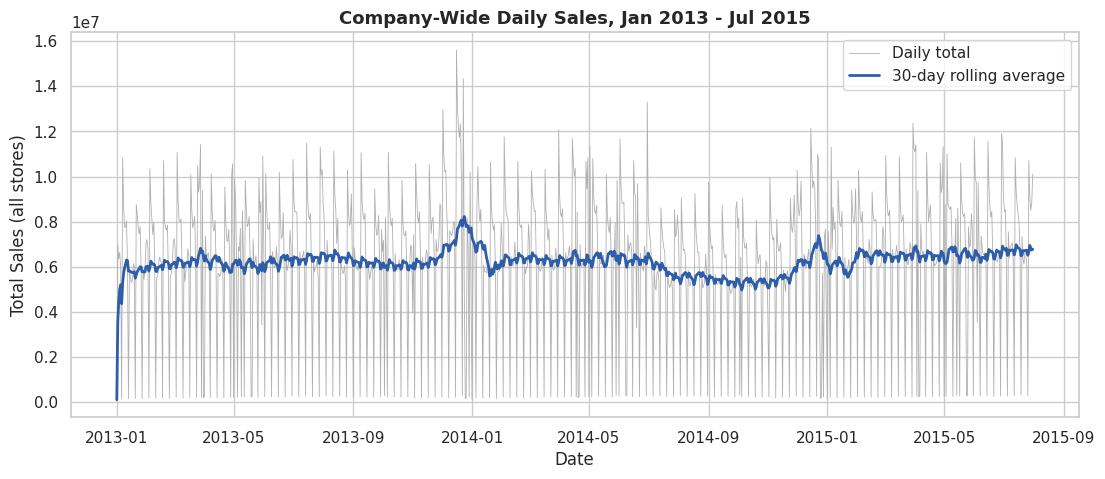

In [4]:
daily_total = df.groupby("Date")["Sales"].sum().reset_index()
daily_total["Rolling30"] = daily_total["Sales"].rolling(30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(daily_total["Date"], daily_total["Sales"], color=MUTED, linewidth=0.6, label="Daily total")
ax.plot(daily_total["Date"], daily_total["Rolling30"], color=PRIMARY, linewidth=2, label="30-day rolling average")
ax.set_title("Company-Wide Daily Sales, Jan 2013 - Jul 2015", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Total Sales (all stores)")
ax.legend()
save_chart(fig, "01_sales_trend_over_time.png", CHARTS_DIR)
plt.show()

**Observation:** the jagged daily line reflects the weekly open/close cycle
(most stores close Sundays), which the 30-day rolling average smooths out. That
smoothed line shows year-end spikes each December and no clear long-term upward
or downward drift across the ~2.5-year window — revenue is essentially stable at
the aggregate level, with strong recurring seasonality rather than structural
growth or decline.

**Business conclusion:** the business is seasonally stable, not currently
growing or shrinking in aggregate. Forecasting should prioritize capturing
seasonal/weekly patterns accurately over trying to model a long-term trend that
doesn't clearly exist in this window.

**Possible business action:** don't budget for organic aggregate growth without
new stores or interventions (promotions, assortment changes) — the base trend
alone won't deliver it.


---
## 2. Monthly Sales Pattern
**Category:** Sales Analysis
**Business question:** Which calendar months are strongest and weakest for
revenue, once we correct for the fact that the dataset covers different numbers
of years for different months?


Saved chart: 02_monthly_sales_pattern.png


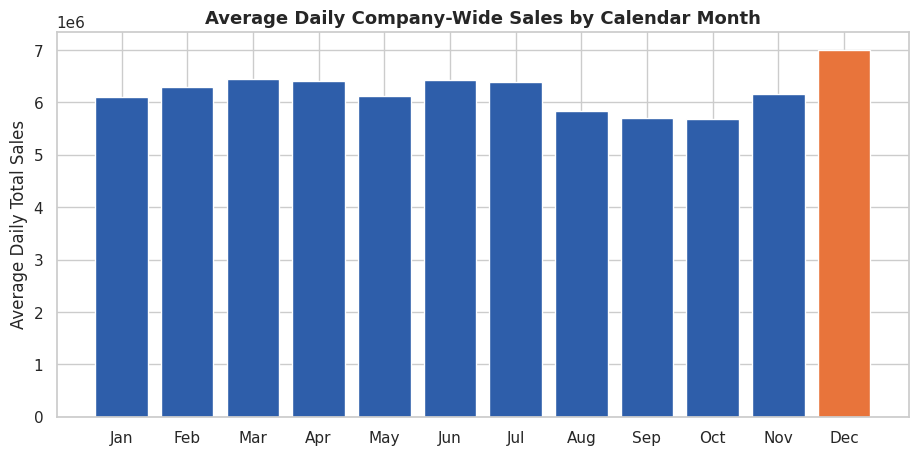

In [5]:
daily_total["Month"] = daily_total["Date"].dt.month
monthly_avg = daily_total.groupby("Month")["Sales"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(11, 5))
colors = [ACCENT if m == monthly_avg.idxmax() else PRIMARY for m in monthly_avg.index]
ax.bar(month_names, monthly_avg.values, color=colors)
ax.set_title("Average Daily Company-Wide Sales by Calendar Month", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Daily Total Sales")
save_chart(fig, "02_monthly_sales_pattern.png", CHARTS_DIR)
plt.show()

**Methodology note:** this uses the *average* daily total per calendar
month, not the raw sum. The raw sum would be misleading here — Jan-Jul each
appear in 3 different years of this dataset, while Aug-Dec only appear in 2
(the data ends July 2015), so a sum-based chart would make the second half of
the year look artificially weaker than it really is. Averaging removes that
artifact.

**Observation:** December is the clear peak (~7.0M average daily revenue,
versus a ~5.7-6.4M range for every other month) — a holiday-shopping effect.
September and October are the softest months (~5.7M).

**Business conclusion:** there is a genuine, moderate holiday-season lift in
December, but the rest of the year is fairly flat once fairly measured — the
dramatic year-end spike some naive analyses would show is partly a measurement
artifact, not entirely a real effect.

**Possible business action:** plan inventory and staffing increases specifically
for December, but don't over-provision for a "back half of the year is weak"
narrative — that pattern is much smaller than it first appears.


---
## 3. Day-of-Week Sales Pattern
**Category:** Sales Analysis
**Business question:** Which days of the week, among stores that are actually
open, generate the most average revenue per store?


Saved chart: 03_day_of_week_pattern.png


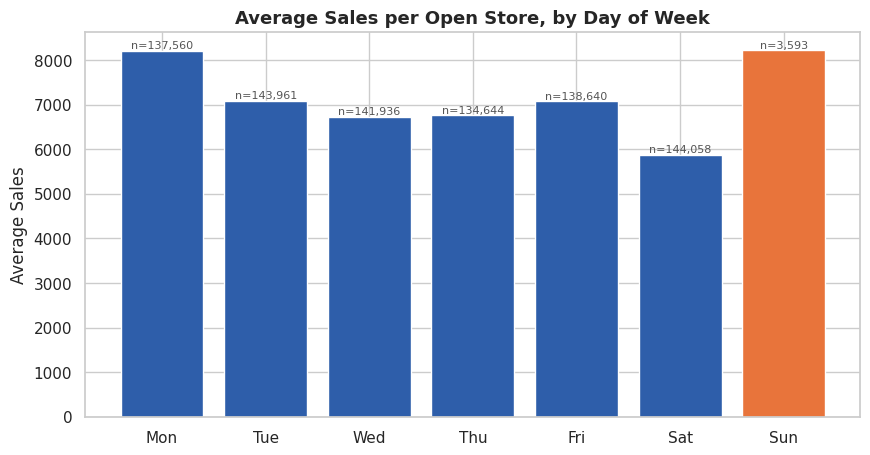

In [6]:
dow_names = {1:"Mon",2:"Tue",3:"Wed",4:"Thu",5:"Fri",6:"Sat",7:"Sun"}
dow_stats = open_df.groupby("DayOfWeek")["Sales"].agg(["mean", "count"])
dow_stats.index = dow_stats.index.map(dow_names)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [ACCENT if n < 10000 else PRIMARY for n in dow_stats["count"]]
bars = ax.bar(dow_stats.index, dow_stats["mean"], color=colors)
for bar, n in zip(bars, dow_stats["count"]):
    ax.annotate(f"n={n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8, color="#555")
ax.set_title("Average Sales per Open Store, by Day of Week", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Sales")
save_chart(fig, "03_day_of_week_pattern.png", CHARTS_DIR)
plt.show()

In [7]:
print(dow_stats)

                  mean   count
DayOfWeek                     
Mon        8216.073074  137560
Tue        7088.113656  143961
Wed        6728.122978  141936
Thu        6767.310159  134644
Fri        7072.677012  138640
Sat        5874.840238  144058
Sun        8224.723908    3593


**Observation:** Monday is the strongest *reliable* day (avg ~8,216,
n=137,560), sales taper through midweek, and Saturday is the softest full-sample
day (avg ~5,875, n=144,058). Sunday shows the *highest* bar of all (avg ~8,225)
— but with only 3,593 open-store rows, versus ~140,000 for every other day.
That's under 0.5% of all open-store days, consistent with German retail law
historically restricting Sunday trading to a small number of exceptions (e.g.
tourist areas, specific store types).

**Business conclusion:** Monday genuinely drives the most reliable revenue per
store. The Sunday figure is **not** a trustworthy "best day" finding — it's a
handful of atypical stores/dates, not a generalizable pattern, and shouldn't
drive a decision like "open more stores on Sundays" without much more targeted
investigation into which stores those are and why.

**Possible business action:** align staffing toward Monday demand; treat the
Sunday result as a flag for further investigation, not an actionable insight on
its own.


---
## 4. Quarterly Sales Pattern
**Category:** Sales Analysis
**Business question:** Which quarter is strongest for revenue, useful for
quarterly business planning and target-setting?


Saved chart: 04_quarterly_sales_pattern.png


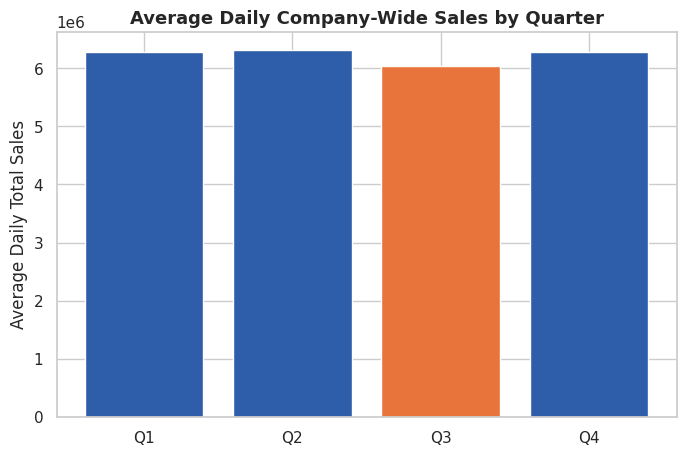

In [8]:
daily_total["Quarter"] = daily_total["Date"].dt.quarter
quarterly_avg = daily_total.groupby("Quarter")["Sales"].mean()
q_labels = [f"Q{q}" for q in quarterly_avg.index]

fig, ax = plt.subplots(figsize=(8, 5))
colors = [ACCENT if q == quarterly_avg.idxmin() else PRIMARY for q in quarterly_avg.index]
ax.bar(q_labels, quarterly_avg.values, color=colors)
ax.set_title("Average Daily Company-Wide Sales by Quarter", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Daily Total Sales")
save_chart(fig, "04_quarterly_sales_pattern.png", CHARTS_DIR)
plt.show()

**Observation:** (same averaging methodology as the monthly chart, for the
same reason.) Q1, Q2, and Q4 are close together (~6.28-6.31M average daily
revenue); Q3 is the only quarter noticeably below the others (~6.04M) — this
lines up with the September/October softness seen in the monthly chart.

**Business conclusion:** revenue is fairly evenly distributed across the year at
the quarter level, with Q3 as the one consistently softer period.

**Possible business action:** if a summer promotional push is being considered,
Q3 is the quarter with room to benefit most from one.


---
## 5. Store Performance: Top and Bottom Performers
**Category:** Store Analysis
**Business question:** Which individual stores are the strongest and weakest
performers, and how large is the gap between them?


Saved chart: 05_store_top_bottom_performance.png


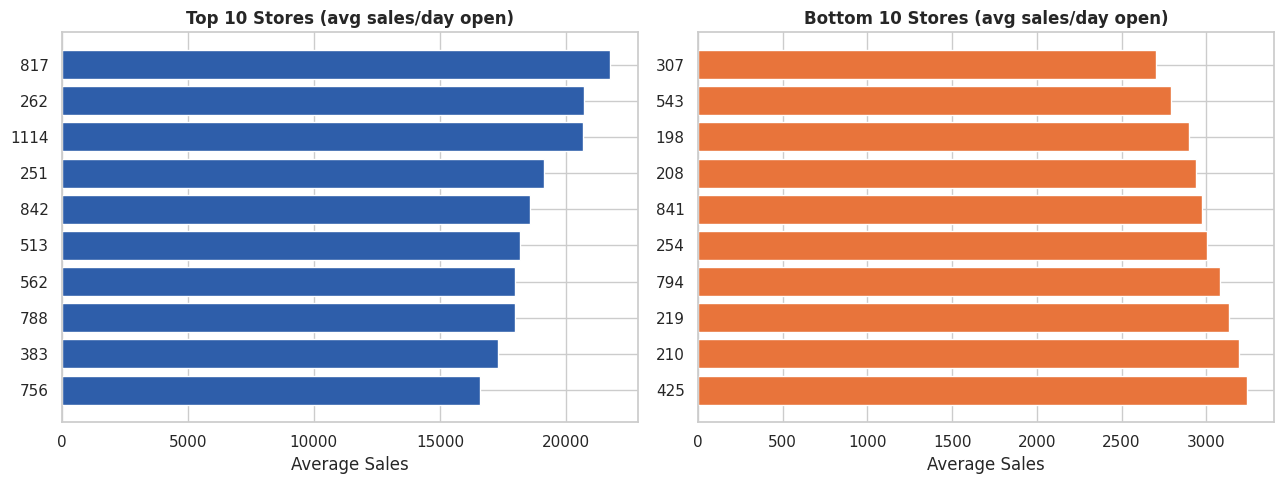

Top store:    #817 - avg 21757/day
Bottom store: #307 - avg 2704/day
Ratio: 8.0x


In [9]:
store_perf = open_df.groupby("Store")["Sales"].mean().sort_values(ascending=False)
top10 = store_perf.head(10)
bottom10 = store_perf.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top10.index.astype(str)[::-1], top10.values[::-1], color=PRIMARY)
axes[0].set_title("Top 10 Stores (avg sales/day open)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Average Sales")

axes[1].barh(bottom10.index.astype(str), bottom10.values, color=ACCENT)
axes[1].set_title("Bottom 10 Stores (avg sales/day open)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Average Sales")

plt.tight_layout()
save_chart(fig, "05_store_top_bottom_performance.png", CHARTS_DIR)
plt.show()

print(f"Top store:    #{top10.index[0]} - avg {top10.iloc[0]:.0f}/day")
print(f"Bottom store: #{bottom10.index[-1]} - avg {bottom10.iloc[-1]:.0f}/day")
print(f"Ratio: {top10.iloc[0] / bottom10.iloc[-1]:.1f}x")

**Observation:** the top store averages roughly **8x** the daily sales of
the bottom store. This is a large, real spread — not measurement noise, since
both are computed only over each store's own open days.

**Business conclusion:** store-level performance varies enormously, likely
driven by a mix of location, size (StoreType), and local competition — factors
we examine next.

**Possible business action:** study what the top-10 stores share in common
(format, assortment, competition distance) as candidates for replication;
investigate whether bottom-10 stores are structurally disadvantaged (e.g. heavy
nearby competition) or genuinely underperforming and worth intervention.


---
## 6. Store Type Comparison (Product-Category Proxy)
**Category:** Product Analysis *(via approved proxy — see architecture doc)*
**Business question:** Which store format (`StoreType`) generates the most
average revenue?


Saved chart: 06_storetype_comparison.png


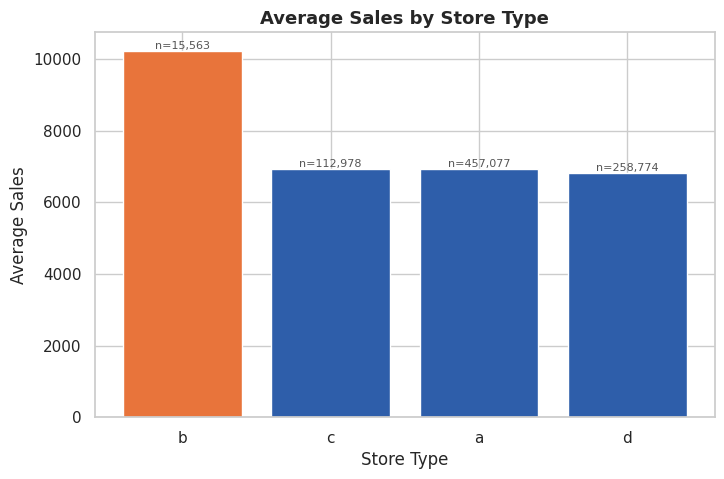

                   mean   count
StoreType                      
b          10231.407505   15563
c           6932.512755  112978
a           6925.167661  457077
d           6822.141881  258774


In [10]:
storetype_stats = open_df.groupby("StoreType")["Sales"].agg(["mean", "count"]).sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [ACCENT if n < 20000 else PRIMARY for n in storetype_stats["count"]]
bars = ax.bar(storetype_stats.index, storetype_stats["mean"], color=colors)
for bar, n in zip(bars, storetype_stats["count"]):
    ax.annotate(f"n={n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8, color="#555")
ax.set_title("Average Sales by Store Type", fontsize=13, fontweight="bold")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Sales")
save_chart(fig, "06_storetype_comparison.png", CHARTS_DIR)
plt.show()

print(storetype_stats)

**Observation:** Type `b` shows the highest average (~10,231) by a wide
margin — but represents only 15,563 open-store rows, versus 457,077 for type
`a`. That's a real but much smaller and more concentrated group (likely a
handful of large-format stores). Types `a`, `c`, and `d` cluster tightly
together (~6,800-6,930).

**Business conclusion:** store format `b` looks like a standout, but the small,
concentrated sample means this is a hypothesis to investigate (are these
genuinely higher-performing large-format stores, or does the small count include
some outliers pulling the average up?) rather than a settled conclusion.

**Possible business action:** examine whether type `b` stores share a specific
location profile (e.g. urban flagship stores) before recommending format
changes to other stores based on this alone.


---
## 7. Assortment Comparison (Product-Category Proxy)
**Category:** Product Analysis *(via approved proxy)*
**Business question:** Does offering a wider product assortment correlate with
higher sales?


Saved chart: 07_assortment_comparison.png


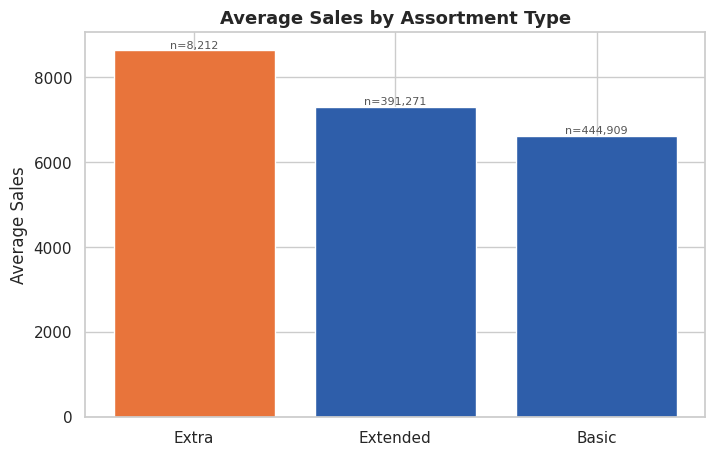

                   mean   count
Assortment                     
b           8639.346322    8212
c           7300.526339  391271
a           6621.017039  444909


In [11]:
assortment_stats = open_df.groupby("Assortment")["Sales"].agg(["mean", "count"]).sort_values("mean", ascending=False)
assortment_labels = {"a": "Basic", "b": "Extra", "c": "Extended"}

fig, ax = plt.subplots(figsize=(8, 5))
colors = [ACCENT if n < 20000 else PRIMARY for n in assortment_stats["count"]]
labels = [assortment_labels[a] for a in assortment_stats.index]
bars = ax.bar(labels, assortment_stats["mean"], color=colors)
for bar, n in zip(bars, assortment_stats["count"]):
    ax.annotate(f"n={n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8, color="#555")
ax.set_title("Average Sales by Assortment Type", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Sales")
save_chart(fig, "07_assortment_comparison.png", CHARTS_DIR)
plt.show()

print(assortment_stats)

**Observation:** "Extra" assortment stores average the highest sales
(~8,639), but again on a small sample (n=8,212). "Extended" assortment (~7,301)
outperforms "Basic" (~6,621) on a fair, large-sample comparison (both well over
390,000 rows).

**Business conclusion:** on the two assortment types with robust sample sizes,
a broader product range ("Extended" vs "Basic") is associated with meaningfully
higher average sales — a defensible, evidence-backed finding, unlike the
"Extra" comparison above which needs more data before acting on it.

**Possible business action:** consider testing an assortment upgrade
(Basic to Extended) at a sample of underperforming Basic-assortment stores,
tracking before/after sales.


---
## 8. Promotion Impact
**Category:** Promotion Analysis
**Business question:** Does running a same-day promotion (`Promo`) actually
move sales, and by how much?


Saved chart: 08_promo_impact.png


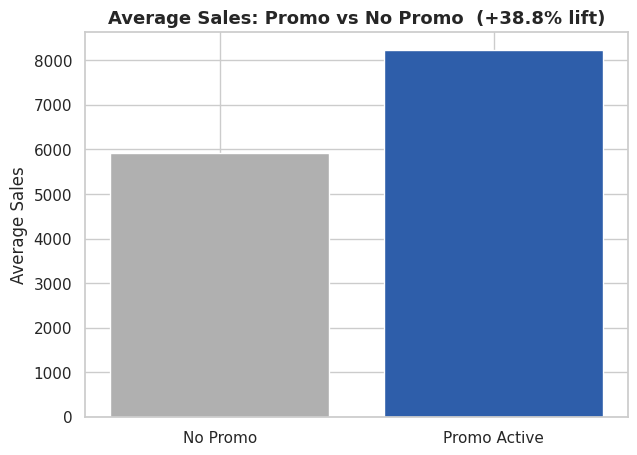

No promo: 5929 (n=467,496)
Promo:    8228 (n=376,896)
Lift: +38.8%


In [12]:
promo_stats = open_df.groupby("Promo")["Sales"].agg(["mean", "count"])
lift_pct = (promo_stats.loc[1, "mean"] / promo_stats.loc[0, "mean"] - 1) * 100

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["No Promo", "Promo Active"], promo_stats["mean"], color=[MUTED, PRIMARY])
ax.set_title(f"Average Sales: Promo vs No Promo  (+{lift_pct:.1f}% lift)", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Sales")
save_chart(fig, "08_promo_impact.png", CHARTS_DIR)
plt.show()

print(f"No promo: {promo_stats.loc[0,'mean']:.0f} (n={promo_stats.loc[0,'count']:,})")
print(f"Promo:    {promo_stats.loc[1,'mean']:.0f} (n={promo_stats.loc[1,'count']:,})")
print(f"Lift: +{lift_pct:.1f}%")

**Observation:** promoted days average roughly **39% higher** sales than
non-promoted days, on very large, comparable sample sizes on both sides — this
is a strong, statistically well-supported effect, not a small-sample artifact.

**Business conclusion:** same-day promotions have a clear, sizeable positive
association with sales. (Note: this compares promo vs non-promo days across all
stores, not a true controlled experiment — some of this lift could reflect
promotions being timed around already-strong sales periods. Still, a 39% gap on
this much data is a meaningful signal either way.)

**Possible business action:** promotions appear to be effective at driving
volume; the next question — outside this notebook's scope — is whether the
revenue lift outweighs the margin given up on the discount itself.


---
## 9. Recurring Promotion (Promo2) Impact
**Category:** Promotion Analysis
**Business question:** Do stores enrolled in the ongoing `Promo2` program show
higher average sales than stores that aren't enrolled?


Saved chart: 09_promo2_impact.png


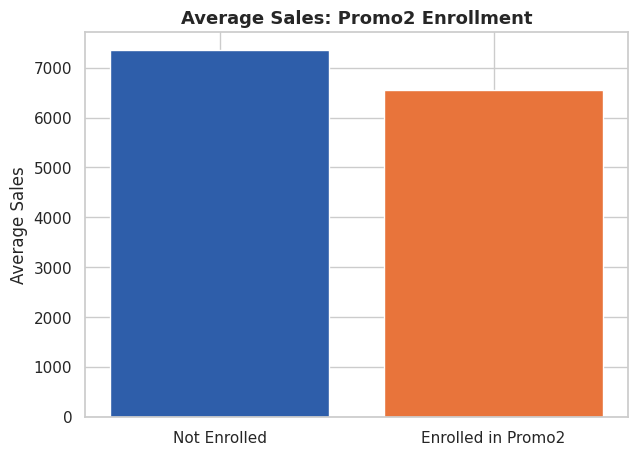

               mean   count
Promo2                     
0       7350.557935  423307
1       6558.386062  421085


In [13]:
promo2_stats = open_df.groupby("Promo2")["Sales"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Not Enrolled", "Enrolled in Promo2"], promo2_stats["mean"], color=[PRIMARY, ACCENT])
ax.set_title("Average Sales: Promo2 Enrollment", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Sales")
save_chart(fig, "09_promo2_impact.png", CHARTS_DIR)
plt.show()

print(promo2_stats)

**Observation - and an important interpretation caveat:** stores enrolled
in `Promo2` actually average *lower* sales than stores that aren't enrolled.

**This does not mean recurring promotions hurt sales.** This is a between-store
comparison, not a before/after comparison for the same stores. A very plausible
explanation: `Promo2` enrollment is a store-level decision, so it's entirely
possible that smaller or lower-traffic stores are more likely to opt into (or be
enrolled in) an ongoing promotional program specifically *because* they need the
boost — meaning the enrolled group may have started lower, not been dragged
lower by the program. Treating this as "Promo2 doesn't work" or "Promo2 causes
losses" would be a real analytical mistake — correlation direction here is
genuinely ambiguous with this data alone.

**Business conclusion:** no causal claim can be responsibly made from this chart
alone.

**Possible business action:** a proper before/after comparison — sales for the
same stores in the weeks immediately before vs after Promo2 enrollment — would
be needed to actually answer whether the program works. Flagging this as a
follow-up analysis rather than guessing.


---
## 10. Holiday Impact
**Category:** Seasonal Analysis
**Business question:** How do public holidays affect sales for the stores that
remain open?


Saved chart: 10_holiday_impact.png


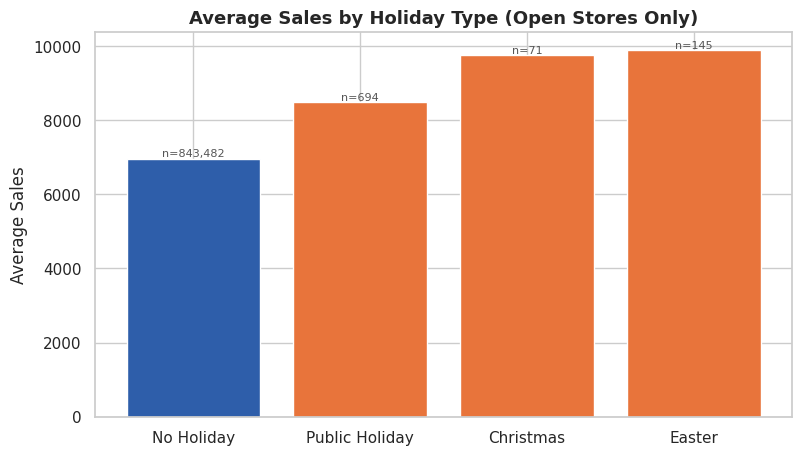

                       mean   count
StateHoliday                       
No Holiday      6953.515034  843482
Public Holiday  8487.471182     694
Christmas       9743.746479      71
Easter          9887.889655     145


In [14]:
holiday_labels = {"0": "No Holiday", "a": "Public Holiday", "b": "Easter", "c": "Christmas"}
holiday_stats = open_df.groupby("StateHoliday")["Sales"].agg(["mean", "count"])
holiday_stats.index = holiday_stats.index.map(holiday_labels)
holiday_stats = holiday_stats.sort_values("mean")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PRIMARY if n > 10000 else ACCENT for n in holiday_stats["count"]]
bars = ax.bar(holiday_stats.index, holiday_stats["mean"], color=colors)
for bar, n in zip(bars, holiday_stats["count"]):
    ax.annotate(f"n={n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8, color="#555")
ax.set_title("Average Sales by Holiday Type (Open Stores Only)", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Sales")
save_chart(fig, "10_holiday_impact.png", CHARTS_DIR)
plt.show()

print(holiday_stats)

**Observation:** every holiday category (Public, Easter, Christmas) shows
*higher* average sales than regular days — but on very small samples (71-694
rows, versus 843,482 regular-day rows; together, holidays are under 0.11% of all
open-store days).

**Business conclusion:** the most plausible explanation isn't "holidays boost
demand" broadly — it's that only a small, self-selected subset of stores choose
or are permitted to stay open on holidays, and those stores likely capture
concentrated demand precisely because most competitors are closed that day.
This is a real, interesting pattern, but it describes the *few stores that open*
on holidays, not holidays' effect on demand generally.

**Possible business action:** identify which specific stores stay open on
holidays and treat "stay open on major holidays" as a potential deliberate
strategy worth testing more broadly — but don't extrapolate this to "sales
generally spike on holidays," which the data doesn't support (99.9%+ of stores
are closed and contribute zero on those days).


---
## 11. Weekend Impact
**Category:** Seasonal Analysis
**Business question:** Are weekends stronger or weaker for sales than weekdays —
relevant for staffing decisions?


Saved chart: 11_weekend_impact.png


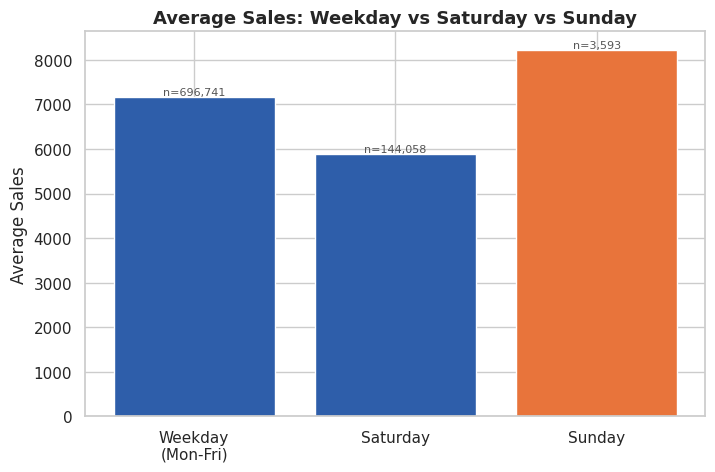

Weekday avg: 7172 (n=696,741)
Saturday avg: 5875 (n=144,058)
Sunday avg: 8225 (n=3,593)


In [15]:
weekday_df = open_df[open_df["DayOfWeek"].isin([1,2,3,4,5])]
saturday_df = open_df[open_df["DayOfWeek"] == 6]
sunday_df = open_df[open_df["DayOfWeek"] == 7]

labels = ["Weekday\n(Mon-Fri)", "Saturday", "Sunday"]
means = [weekday_df["Sales"].mean(), saturday_df["Sales"].mean(), sunday_df["Sales"].mean()]
counts = [len(weekday_df), len(saturday_df), len(sunday_df)]

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PRIMARY, PRIMARY, ACCENT]
bars = ax.bar(labels, means, color=colors)
for bar, n in zip(bars, counts):
    ax.annotate(f"n={n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha="center", va="bottom", fontsize=8, color="#555")
ax.set_title("Average Sales: Weekday vs Saturday vs Sunday", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Sales")
save_chart(fig, "11_weekend_impact.png", CHARTS_DIR)
plt.show()

print(f"Weekday avg: {weekday_df['Sales'].mean():.0f} (n={len(weekday_df):,})")
print(f"Saturday avg: {saturday_df['Sales'].mean():.0f} (n={len(saturday_df):,})")
print(f"Sunday avg: {sunday_df['Sales'].mean():.0f} (n={len(sunday_df):,})")

**Observation:** on a fair, large-sample basis, Saturday (avg ~5,875,
n=144,058) is actually *lower* than the weekday average (avg ~7,172,
n=696,741). Sunday's average looks highest (~8,225) but rests on only 3,593
rows (0.4% of open-store days) — the same small-sample caveat from chart #3.

**Business conclusion:** weekends are not stronger for sales at this company —
if anything, Saturday is the weakest reliably-measured day of the week. The
"Sunday is best" signal is not dependable evidence given how few stores operate
that day.

**Possible business action:** don't over-staff for weekend demand generally;
Monday-Friday, not the weekend, is where the reliable revenue is. Any
Sunday-opening strategy should be piloted and measured on its own terms rather
than assumed profitable from this pattern.


---
## 12. Correlation Analysis
**Category:** Correlation Analysis
**Business question:** Which numeric factors are most strongly associated with
`Sales`, to help prioritize what feature engineering (Notebook 04) should focus
on?


Saved chart: 12_correlation_heatmap.png


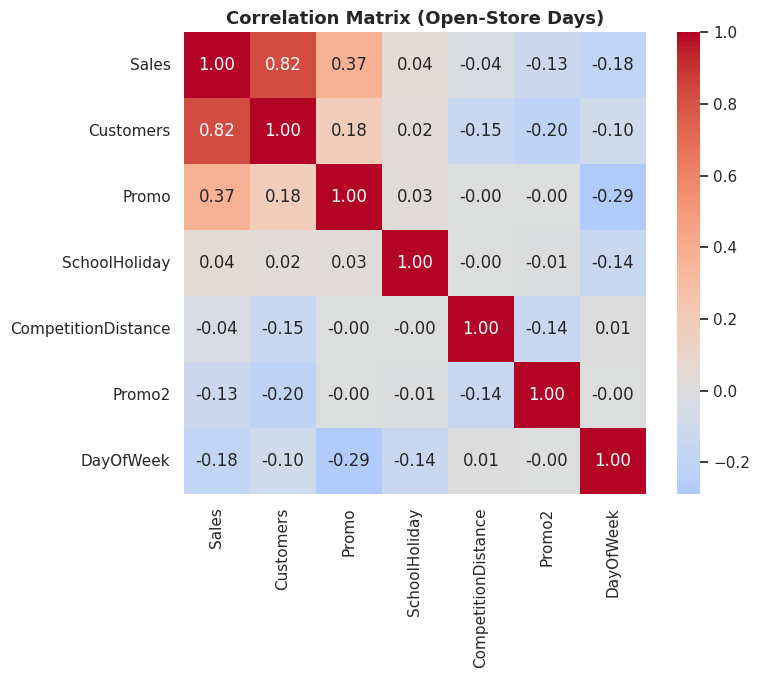

Sales                  1.000000
Customers              0.823597
Promo                  0.368145
SchoolHoliday          0.038617
CompetitionDistance   -0.035851
Promo2                -0.127596
DayOfWeek             -0.178736
Name: Sales, dtype: float64


In [16]:
num_cols = ["Sales", "Customers", "Promo", "SchoolHoliday", "CompetitionDistance", "Promo2", "DayOfWeek"]
corr = open_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation Matrix (Open-Store Days)", fontsize=13, fontweight="bold")
save_chart(fig, "12_correlation_heatmap.png", CHARTS_DIR)
plt.show()

print(corr["Sales"].sort_values(ascending=False))

**Observation:** `Customers` is by far the strongest correlate with `Sales`
(0.82) — unsurprising, but confirms foot traffic is the dominant driver.
`Promo` (0.37) is the next strongest, consistent with chart #8's 39% lift.
`DayOfWeek` (-0.18) and `Promo2` (-0.13) show mild negative correlations;
`SchoolHoliday` (0.04) and `CompetitionDistance` (-0.04) are both close to zero.

**Business conclusion:** `Customers` and `Promo` are the features most worth
engineering carefully around, since they carry the clearest linear relationship
with `Sales`. `CompetitionDistance`'s near-zero correlation is itself a finding
— competitor proximity does not appear to meaningfully suppress this chain's
sales in a simple linear sense (a more complex, non-linear relationship is still
possible and worth testing with tree-based models later).

**Possible business action:** if a future dataset includes real-time footfall or
staffing data, `Customers` is the highest-leverage lever to instrument further;
competitive-distance-based strategy (e.g. avoiding locations near competitors)
isn't strongly supported by this simple analysis.


## EDA Summary - Consolidated Business Insights

| # | Finding | Confidence |
|---|---|---|
| 1 | Aggregate revenue is seasonally stable, no clear multi-year growth/decline | High (full dataset) |
| 2 | December is the genuine seasonal peak; rest of year fairly flat once fairly measured | High |
| 3 | Monday is the strongest reliable weekday; Sunday's high average is a small-sample artifact | High for Monday / Low for Sunday |
| 4 | Q3 (Jul-Sep) is the consistently softest quarter | High |
| 5 | ~8x spread between best and worst individual stores | High |
| 6 | Store Type `b` and Assortment `b` show highest averages but on small samples | Low-Medium (needs more data) |
| 7 | Extended assortment outperforms Basic on a robust sample | High |
| 8 | Same-day promotions show a strong, well-supported +39% lift | High |
| 9 | Promo2 enrollment shows lower average sales - likely selection effect, not causal harm | Inconclusive (needs before/after study) |
| 10 | Stores open on holidays see higher averages - reflects concentrated demand at rare open stores, not a broad holiday effect | Low sample, real pattern for the open subset |
| 11 | Weekends are not stronger than weekdays; Saturday is the weakest reliable day | High |
| 12 | `Customers` and `Promo` are the strongest linear correlates with `Sales` | High |


## Next Steps

Notebook 04 (`04_feature_engineering.ipynb`) will build directly on these
findings: date-based features (month, quarter, day-of-week, weekend flags) to
capture the seasonal patterns found here, and promotion/holiday flags to capture
findings #8-10 - each justified by a specific chart above rather than engineered
speculatively.
